# 05: Parallel Trends and Event Studies

Parallel trends is the identifying assumption behind DiD. It
does not say treated and control groups have the same level. It
says the control group provides a plausible counterfactual trend
for the treated group.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
scenarios = pd.read_csv(DATA_DIR / "trend_scenarios_panel.csv")
scenarios["scenario"].value_counts()


scenario
valid_parallel          324
nonparallel_pretrend    324
anticipation            324
spillover               324
Name: count, dtype: int64

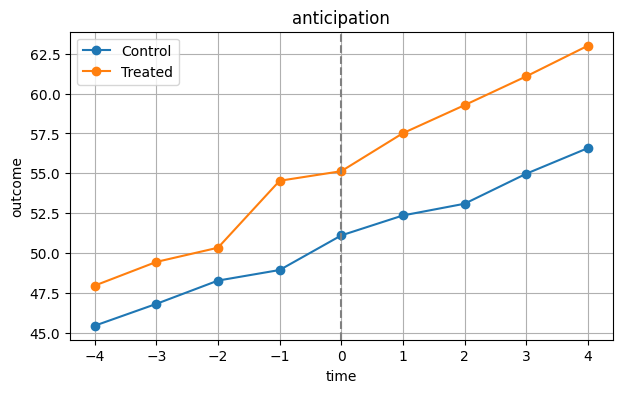

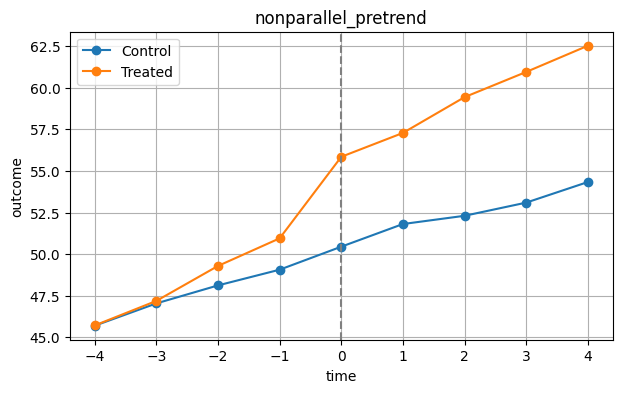

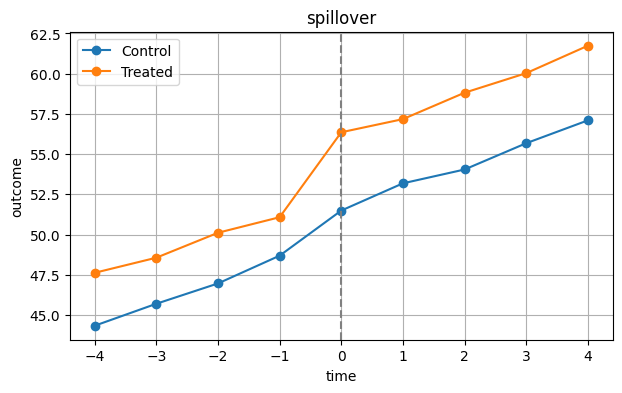

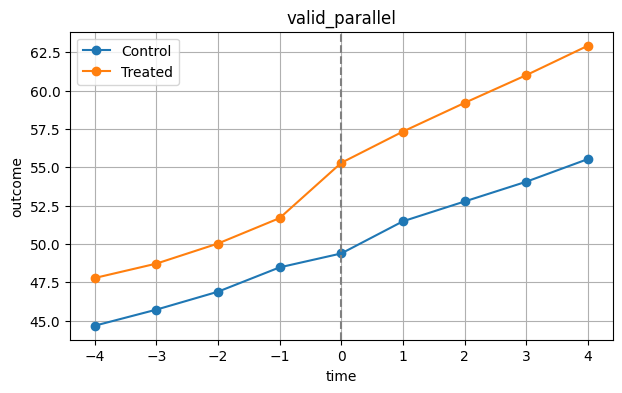

In [3]:
for scenario, part in scenarios.groupby("scenario"):
    plot_group_trends(part, "outcome", "time", "treated", title=scenario)
    plt.axvline(0, color="gray", linestyle="--")
    plt.show()


## Event-study setup

We create treated-by-relative-time indicators and omit period
`-1` as the reference period. Lead coefficients before treatment
should be close to zero when pre-trends are plausible.

The event-study regression has the form

`outcome_it = alpha_i + lambda_t + sum_k beta_k * treated_i * 1[relative_time_t = k] + error_it`,

omitting `k = -1`. Coefficients with `k < 0` are leads and are
mainly diagnostic. Coefficients with `k >= 0` are post-treatment
lags and describe how the treatment effect evolves over time.


In [4]:
valid = scenarios.query("scenario == 'valid_parallel'").copy()
event_data, event_cols = make_event_dummies(
    valid,
    rel_time_col="relative_time",
    treated_col="treated",
    omit=-1,
    window=(-4, 4),
)

formula = "outcome ~ " + " + ".join(event_cols) + " + C(unit_id) + C(time)"
event_model = smf.ols(formula, data=event_data).fit(
    cov_type="cluster",
    cov_kwds={"groups": event_data["unit_id"]},
)

event_results = extract_event_study_results(event_model)
event_results


,relative_time,estimate,std_error
0,-4,-0.101667,0.562774
1,-3,-0.212222,0.581074
2,-2,-0.071667,0.577042
3,0,2.694444,0.556543
4,1,2.636667,0.596032
5,2,3.213333,0.525097
6,3,3.733889,0.564107
7,4,4.175556,0.497513


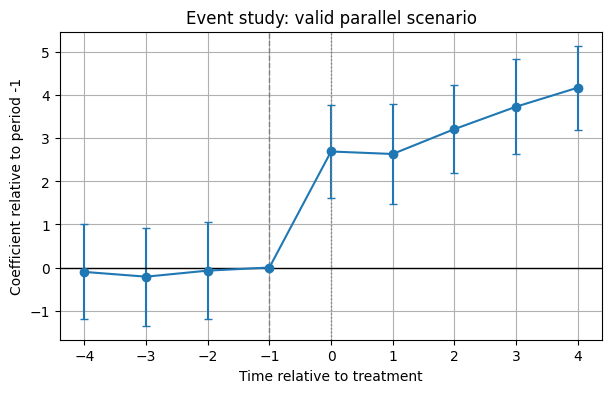

In [5]:
plot_event_study(event_results, reference=-1, title="Event study: valid parallel scenario")
plt.show()


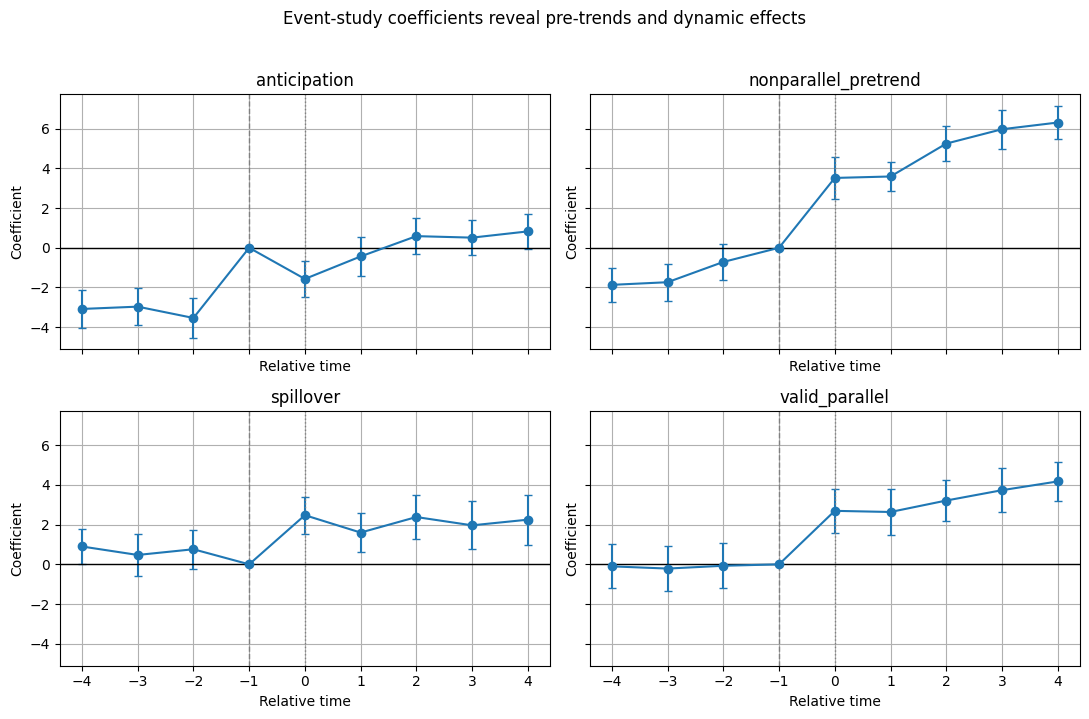

In [6]:
scenario_events = []
for scenario, part in scenarios.groupby("scenario"):
    event_part, cols = make_event_dummies(
        part,
        rel_time_col="relative_time",
        treated_col="treated",
        omit=-1,
        window=(-4, 4),
    )
    scenario_formula = "outcome ~ " + " + ".join(cols) + " + C(unit_id) + C(time)"
    fit = smf.ols(scenario_formula, data=event_part).fit(
        cov_type="cluster",
        cov_kwds={"groups": event_part["unit_id"]},
    )
    results = extract_event_study_results(fit)
    results["scenario"] = scenario
    scenario_events.append(results)

all_event_results = pd.concat(scenario_events, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (scenario, part) in zip(axes.ravel(), all_event_results.groupby("scenario")):
    plot_part = pd.concat(
        [
            part,
            pd.DataFrame({"relative_time": [-1], "estimate": [0.0], "std_error": [0.0], "scenario": [scenario]}),
        ],
        ignore_index=True,
    ).sort_values("relative_time")
    ax.errorbar(
        plot_part["relative_time"],
        plot_part["estimate"],
        yerr=1.96 * plot_part["std_error"],
        marker="o",
        capsize=3,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(-1, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(scenario)
    ax.set_xlabel("Relative time")
    ax.set_ylabel("Coefficient")
fig.suptitle("Event-study coefficients reveal pre-trends and dynamic effects", y=1.02)
fig.tight_layout()
plt.show()


Two cautions matter when reading these event-study plots. First,
an anticipation effect in the omitted reference period can make
earlier leads look nonzero because those leads are compared to
an already affected period. Second, spillovers can leave
pre-treatment leads looking harmless while still biasing the
post-treatment comparison.


In [7]:
pre_leads = event_results.query("relative_time < 0")["estimate"].abs()
print(f"Largest absolute pre-treatment lead: {pre_leads.max():.3f}")


Largest absolute pre-treatment lead: 0.212


Takeaway: plots and event-study leads can support the parallel
trends story, but they do not prove it. DiD still requires an
argument about why the comparison group is credible.
